In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    recall_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

master_df = pd.read_csv(
    PROCESSED_DATA / "master_dataset.csv"
)

print("Master dataset shape:", master_df.shape)

display(master_df.head())

Master dataset shape: (3834, 18)


,CustomerID,response,n_comp,loyalty,nps,n_communications,total_sales,unique_products,number_of_invoices,purchase_days,cancelled_invoices,cancellation_value,net_sales,average_order_value,total_invoice_activity,cancellation_rate,nps_category,has_cancellation
0,12346,1,2,1,7.0,8,77183.60,1,1,1,1,77183.60,0.00,77183.600000,2,0.500000,Passive,1
1,12747,0,1,1,3.0,3,3489.74,39,9,9,0,0.00,3489.74,387.748889,9,0.000000,Detractor,0
2,12748,1,0,1,9.0,6,28868.19,1602,175,100,12,4597.18,24271.01,164.961086,187,0.064171,Promoter,1
3,12749,0,4,1,2.0,5,4090.88,160,5,4,3,222.68,3868.20,818.176000,8,0.375000,Detractor,1
4,12820,0,4,1,2.0,2,942.34,55,4,4,0,0.00,942.34,235.585000,4,0.000000,Detractor,0


In [3]:
print("Response distribution:")
display(
    master_df["response"]
    .value_counts()
    .sort_index()
)

print("\nResponse rate:")
print(
    round(master_df["response"].mean() * 100, 2),
    "%"
)

print("\nMissing values in modelling variables:")

model_columns = [
    "total_sales",
    "unique_products",
    "number_of_invoices",
    "nps",
    "n_comp",
    "n_communications",
    "loyalty",
    "response"
]

display(
    master_df[model_columns]
    .isna()
    .sum()
)

Response distribution:


response
0    2279
1    1555
Name: count, dtype: int64


Response rate:
40.56 %

Missing values in modelling variables:


total_sales           0
unique_products       0
number_of_invoices    0
nps                   3
n_comp                0
n_communications      0
loyalty               0
response              0
dtype: int64

In [4]:
features = [
    "total_sales",
    "unique_products",
    "number_of_invoices",
    "nps",
    "n_comp",
    "n_communications",
    "loyalty"
]

X = master_df[features].copy()
y = master_df["response"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining response rate:")
print(round(y_train.mean() * 100, 2), "%")

print("\nTest response rate:")
print(round(y_test.mean() * 100, 2), "%")

print("\nMissing NPS values:")
print("Train:", X_train["nps"].isna().sum())
print("Test:", X_test["nps"].isna().sum())

Training set: (3067, 7)
Test set: (767, 7)

Training response rate:
40.56 %

Test response rate:
40.55 %

Missing NPS values:
Train: 3
Test: 0


In [5]:
nps_train_median = X_train["nps"].median()

print("Training NPS median:", nps_train_median)

X_train["nps"] = X_train["nps"].fillna(nps_train_median)
X_test["nps"] = X_test["nps"].fillna(nps_train_median)

print("\nMissing NPS after imputation:")
print("Train:", X_train["nps"].isna().sum())
print("Test:", X_test["nps"].isna().sum())

Training NPS median: 5.0

Missing NPS after imputation:
Train: 0
Test: 0


In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

print("Training means:")
display(X_train_scaled.mean().round(2))

print("\nTraining standard deviations:")
display(X_train_scaled.std().round(2))

Training means:


total_sales           0.0
unique_products      -0.0
number_of_invoices   -0.0
nps                  -0.0
n_comp               -0.0
n_communications     -0.0
loyalty               0.0
dtype: float64


Training standard deviations:


total_sales           1.0
unique_products       1.0
number_of_invoices    1.0
nps                   1.0
n_comp                1.0
n_communications      1.0
loyalty               1.0
dtype: float64

In [8]:
logistic_model = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic regression trained successfully.")

Logistic regression trained successfully.


c:\Users\Precision5540\Desktop\G7_Retail_Analytics_Final_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [9]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Odds_Ratio"] = np.exp(
    coefficients["Coefficient"]
)

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

display(coefficients.round(4))

,Feature,Coefficient,Odds_Ratio
3,nps,0.4732,1.6051
6,loyalty,0.2923,1.3395
5,n_communications,0.2258,1.2533
0,total_sales,0.0173,1.0174
1,unique_products,-0.0191,0.9810
2,number_of_invoices,-0.0328,0.9677
4,n_comp,-0.1300,0.8781


In [10]:
train_probabilities = logistic_model.predict_proba(
    X_train_scaled
)[:, 1]

train_auc = roc_auc_score(
    y_train,
    train_probabilities
)

print("Training ROC AUC:", round(train_auc, 4))

Training ROC AUC: 0.6725


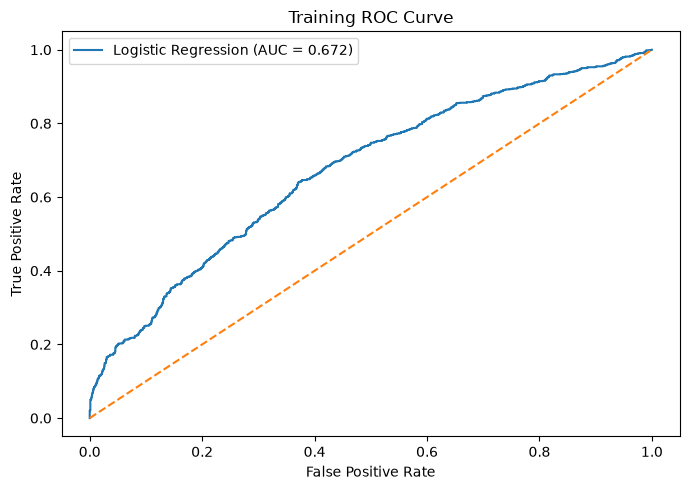

In [11]:
fpr_train, tpr_train, thresholds_train = roc_curve(
    y_train,
    train_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"Logistic Regression (AUC = {train_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Training ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
train_predictions_05 = (
    train_probabilities >= 0.50
).astype(int)

train_confusion_matrix = confusion_matrix(
    y_train,
    train_predictions_05
)

print("Confusion Matrix:")
print(train_confusion_matrix)

Confusion Matrix:
[[1489  334]
 [ 755  489]]


In [13]:
tn, fp, fn, tp = train_confusion_matrix.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

balanced_accuracy = (
    sensitivity + specificity
) / 2

print("Accuracy:", round(accuracy, 4))
print("Sensitivity:", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))
print(
    "Balanced Accuracy:",
    round(balanced_accuracy, 4)
)

Accuracy: 0.6449
Sensitivity: 0.3931
Specificity: 0.8168
Balanced Accuracy: 0.6049


In [14]:
threshold_results = pd.DataFrame({
    "Threshold": thresholds_train,
    "Sensitivity": tpr_train,
    "Specificity": 1 - fpr_train
})

threshold_results["Difference"] = abs(
    threshold_results["Sensitivity"]
    - threshold_results["Specificity"]
)

best_threshold_row = (
    threshold_results
    .sort_values("Difference")
    .iloc[0]
)

display(best_threshold_row.round(4))

Threshold      0.4038
Sensitivity    0.6318
Specificity    0.6314
Difference     0.0005
Name: 618, dtype: float64

In [15]:
best_threshold = best_threshold_row["Threshold"]

train_predictions_opt = (
    train_probabilities >= best_threshold
).astype(int)

train_confusion_matrix_opt = confusion_matrix(
    y_train,
    train_predictions_opt
)

print("Optimised Confusion Matrix:")
print(train_confusion_matrix_opt)

Optimised Confusion Matrix:
[[1151  672]
 [ 458  786]]


In [16]:
tn, fp, fn, tp = train_confusion_matrix_opt.ravel()

accuracy_opt = (tp + tn) / (tp + tn + fp + fn)

sensitivity_opt = tp / (tp + fn)

specificity_opt = tn / (tn + fp)

balanced_accuracy_opt = (
    sensitivity_opt + specificity_opt
) / 2

print("Optimised Threshold:", round(best_threshold, 4))
print("Accuracy:", round(accuracy_opt, 4))
print("Sensitivity:", round(sensitivity_opt, 4))
print("Specificity:", round(specificity_opt, 4))
print("Balanced Accuracy:", round(balanced_accuracy_opt, 4))

Optimised Threshold: 0.4038
Accuracy: 0.6316
Sensitivity: 0.6318
Specificity: 0.6314
Balanced Accuracy: 0.6316


In [17]:
test_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

test_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("Training ROC AUC:", round(train_auc, 4))
print("Test ROC AUC:", round(test_auc, 4))

Training ROC AUC: 0.6725
Test ROC AUC: 0.6391


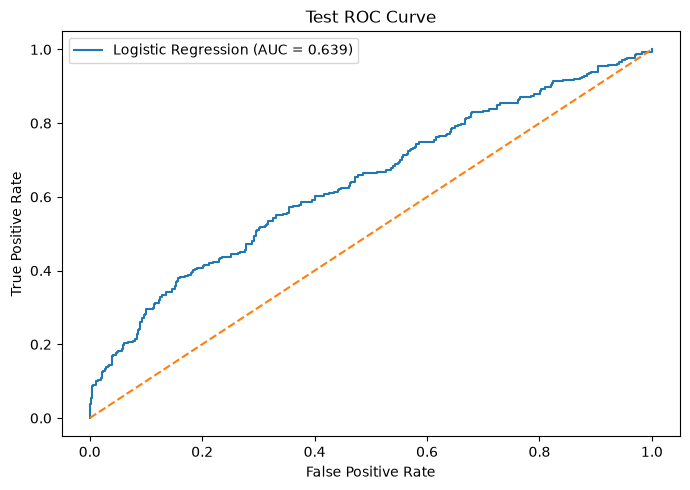

In [18]:
fpr_test, tpr_test, thresholds_test = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Logistic Regression (AUC = {test_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
test_predictions_opt = (
    test_probabilities >= best_threshold
).astype(int)

test_confusion_matrix_opt = confusion_matrix(
    y_test,
    test_predictions_opt
)

print("Test Confusion Matrix:")
print(test_confusion_matrix_opt)

Test Confusion Matrix:
[[291 165]
 [132 179]]


In [20]:
tn, fp, fn, tp = test_confusion_matrix_opt.ravel()

test_accuracy = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

test_sensitivity = (
    tp / (tp + fn)
)

test_specificity = (
    tn / (tn + fp)
)

test_balanced_accuracy = (
    test_sensitivity + test_specificity
) / 2

print("Threshold:", round(best_threshold, 4))
print("Accuracy:", round(test_accuracy, 4))
print("Sensitivity:", round(test_sensitivity, 4))
print("Specificity:", round(test_specificity, 4))
print(
    "Balanced Accuracy:",
    round(test_balanced_accuracy, 4)
)

Threshold: 0.4038
Accuracy: 0.6128
Sensitivity: 0.5756
Specificity: 0.6382
Balanced Accuracy: 0.6069


In [21]:
performance_comparison = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Balanced Accuracy"
    ],
    "Training": [
        train_auc,
        accuracy_opt,
        sensitivity_opt,
        specificity_opt,
        balanced_accuracy_opt
    ],
    "Test": [
        test_auc,
        test_accuracy,
        test_sensitivity,
        test_specificity,
        test_balanced_accuracy
    ]
})

display(
    performance_comparison.round(4)
)

,Metric,Training,Test
0,ROC AUC,0.6725,0.6391
1,Accuracy,0.6316,0.6128
2,Sensitivity,0.6318,0.5756
3,Specificity,0.6314,0.6382
4,Balanced Accuracy,0.6316,0.6069


In [22]:
import statsmodels.api as sm

In [23]:
X_train_stats = sm.add_constant(
    X_train_scaled
)

logit_stats_model = sm.Logit(
    y_train,
    X_train_stats
)

logit_stats_result = logit_stats_model.fit()

print(
    logit_stats_result.summary()
)

Optimization terminated successfully.
         Current function value: 0.628615
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               response   No. Observations:                 3067
Model:                          Logit   Df Residuals:                     3059
Method:                           MLE   Df Model:                            7
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                 0.06902
Time:                        15:26:36   Log-Likelihood:                -1928.0
converged:                       True   LL-Null:                       -2070.9
Covariance Type:            nonrobust   LLR p-value:                 6.260e-58
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.4186      0.039    -10.791      0.000      -0.495      -0.343
total

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [25]:
vif_data = pd.DataFrame()

vif_data["Feature"] = features

vif_data["VIF"] = [
    variance_inflation_factor(
        X_train_scaled.values,
        i
    )
    for i in range(X_train_scaled.shape[1])
]

display(
    vif_data
    .sort_values("VIF", ascending=False)
    .round(2)
)

,Feature,VIF
2,number_of_invoices,2.27
1,unique_products,1.79
0,total_sales,1.47
5,n_communications,1.02
3,nps,1.01
6,loyalty,1.01
4,n_comp,1.01


In [26]:
X_train_recoded = X_train.copy()
X_test_recoded = X_test.copy()

print("Training shape:", X_train_recoded.shape)
print("Test shape:", X_test_recoded.shape)

Training shape: (3067, 7)
Test shape: (767, 7)


In [27]:
nps_bins = [-1, 6, 8, 10]
nps_labels = ["Detractor", "Passive", "Promoter"]

X_train_recoded["nps_category"] = pd.cut(
    X_train_recoded["nps"],
    bins=nps_bins,
    labels=nps_labels
)

X_test_recoded["nps_category"] = pd.cut(
    X_test_recoded["nps"],
    bins=nps_bins,
    labels=nps_labels
)

print("Training NPS categories:")
display(
    X_train_recoded["nps_category"]
    .value_counts()
    .sort_index()
)

print("\nTest NPS categories:")
display(
    X_test_recoded["nps_category"]
    .value_counts()
    .sort_index()
)

Training NPS categories:


nps_category
Detractor    2245
Passive       612
Promoter      210
Name: count, dtype: int64


Test NPS categories:


nps_category
Detractor    552
Passive      164
Promoter      51
Name: count, dtype: int64

In [ ]:
for dataset in [X_train_recoded, X_test_recoded]:

    dataset["nps_passive"] = (
        dataset["nps_category"] == "Passive"
    ).astype(int)

    dataset["nps_promoter"] = (
        dataset["nps_category"] == "Promoter"
    ).astype(int)


X_train_recoded = X_train_recoded.drop(
    columns=["nps", "nps_category"]
)

X_test_recoded = X_test_recoded.drop(
    columns=["nps", "nps_category"]
)

print("Training shape:", X_train_recoded.shape)
print("Test shape:", X_test_recoded.shape)

print("\nTraining dummy totals:")
print(
    X_train_recoded[
        ["nps_passive", "nps_promoter"]
    ].sum()
)

print("\nTest dummy totals:")
print(
    X_test_recoded[
        ["nps_passive", "nps_promoter"]
    ].sum()
)

Training shape: (3067, 8)
Test shape: (767, 8)

Training dummy totals:
nps_passive     612
nps_promoter    210
dtype: int64

Test dummy totals:
nps_passive     164
nps_promoter     51
dtype: int64


In [29]:
for dataset in [X_train_recoded, X_test_recoded]:

    for complaints in range(1, 6):
        dataset[f"n_comp_{complaints}"] = (
            dataset["n_comp"] == complaints
        ).astype(int)

X_train_recoded = X_train_recoded.drop(
    columns=["n_comp"]
)

X_test_recoded = X_test_recoded.drop(
    columns=["n_comp"]
)

print("Training shape:", X_train_recoded.shape)
print("Test shape:", X_test_recoded.shape)

print("\nTraining complaint dummies:")
display(
    X_train_recoded[
        [f"n_comp_{i}" for i in range(1, 6)]
    ].sum()
)

print("\nTest complaint dummies:")
display(
    X_test_recoded[
        [f"n_comp_{i}" for i in range(1, 6)]
    ].sum()
)

Training shape: (3067, 12)
Test shape: (767, 12)

Training complaint dummies:


n_comp_1    522
n_comp_2    648
n_comp_3    657
n_comp_4    614
n_comp_5    315
dtype: int64


Test complaint dummies:


n_comp_1    119
n_comp_2    137
n_comp_3    195
n_comp_4    164
n_comp_5     86
dtype: int64

In [30]:
for dataset in [X_train_recoded, X_test_recoded]:

    for communications in range(3, 10):
        dataset[f"n_communications_{communications}"] = (
            dataset["n_communications"] == communications
        ).astype(int)

X_train_recoded = X_train_recoded.drop(
    columns=["n_communications"]
)

X_test_recoded = X_test_recoded.drop(
    columns=["n_communications"]
)

print("Training shape:", X_train_recoded.shape)
print("Test shape:", X_test_recoded.shape)

print("\nTraining communication dummies:")
display(
    X_train_recoded[
        [f"n_communications_{i}" for i in range(3, 10)]
    ].sum()
)

print("\nTest communication dummies:")
display(
    X_test_recoded[
        [f"n_communications_{i}" for i in range(3, 10)]
    ].sum()
)

Training shape: (3067, 18)
Test shape: (767, 18)

Training communication dummies:


n_communications_3    455
n_communications_4    442
n_communications_5    471
n_communications_6    435
n_communications_7    359
n_communications_8    437
n_communications_9    187
dtype: int64


Test communication dummies:


n_communications_3    111
n_communications_4    106
n_communications_5    116
n_communications_6    125
n_communications_7     90
n_communications_8    102
n_communications_9     48
dtype: int64

In [31]:
continuous_features = [
    "total_sales",
    "unique_products",
    "number_of_invoices"
]

recoded_scaler = StandardScaler()

X_train_recoded[continuous_features] = (
    recoded_scaler.fit_transform(
        X_train_recoded[continuous_features]
    )
)

X_test_recoded[continuous_features] = (
    recoded_scaler.transform(
        X_test_recoded[continuous_features]
    )
)

print("Training means:")
display(
    X_train_recoded[continuous_features]
    .mean()
    .round(2)
)

print("\nTraining standard deviations:")
display(
    X_train_recoded[continuous_features]
    .std()
    .round(2)
)

Training means:


total_sales           0.0
unique_products      -0.0
number_of_invoices   -0.0
dtype: float64


Training standard deviations:


total_sales           1.0
unique_products       1.0
number_of_invoices    1.0
dtype: float64

In [32]:
nps_response_check = pd.DataFrame({
    "nps_passive": X_train_recoded["nps_passive"],
    "nps_promoter": X_train_recoded["nps_promoter"],
    "response": y_train
})

print("Passive:")
display(
    pd.crosstab(
        nps_response_check["nps_passive"],
        nps_response_check["response"]
    )
)

print("\nPromoter:")
display(
    pd.crosstab(
        nps_response_check["nps_promoter"],
        nps_response_check["response"]
    )
)

Passive:


response,0,1
nps_passive,,
0,1487,968
1,336,276



Promoter:


response,0,1
nps_promoter,,
0,1823,1034
1,0,210


In [ ]:
for dataset in [X_train_recoded, X_test_recoded]:

    dataset["nps_non_detractor"] = (
        dataset["nps_passive"]
        + dataset["nps_promoter"]
    ).clip(upper=1)


X_train_recoded = X_train_recoded.drop(
    columns=["nps_passive", "nps_promoter"]
)

X_test_recoded = X_test_recoded.drop(
    columns=["nps_passive", "nps_promoter"]
)

print("Training shape:", X_train_recoded.shape)
print("Test shape:", X_test_recoded.shape)

print("\nTraining response by NPS group:")

display(
    pd.crosstab(
        X_train_recoded["nps_non_detractor"],
        y_train
    )
)

Training shape: (3067, 17)
Test shape: (767, 17)

Training response by NPS group:


response,0,1
nps_non_detractor,,
0,1487,758
1,336,486


In [34]:
logistic_model_recoded = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=42
)

logistic_model_recoded.fit(
    X_train_recoded,
    y_train
)

print("Recoded logistic regression trained successfully.")

Recoded logistic regression trained successfully.


c:\Users\Precision5540\Desktop\G7_Retail_Analytics_Final_Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [35]:
train_probabilities_recoded = (
    logistic_model_recoded.predict_proba(
        X_train_recoded
    )[:, 1]
)

test_probabilities_recoded = (
    logistic_model_recoded.predict_proba(
        X_test_recoded
    )[:, 1]
)

train_auc_recoded = roc_auc_score(
    y_train,
    train_probabilities_recoded
)

test_auc_recoded = roc_auc_score(
    y_test,
    test_probabilities_recoded
)

print(
    "Recoded Training ROC AUC:",
    round(train_auc_recoded, 4)
)

print(
    "Recoded Test ROC AUC:",
    round(test_auc_recoded, 4)
)

Recoded Training ROC AUC: 0.6903
Recoded Test ROC AUC: 0.6398


In [36]:
fpr_train_recoded, tpr_train_recoded, thresholds_train_recoded = roc_curve(
    y_train,
    train_probabilities_recoded
)

threshold_results_recoded = pd.DataFrame({
    "Threshold": thresholds_train_recoded,
    "Sensitivity": tpr_train_recoded,
    "Specificity": 1 - fpr_train_recoded
})

threshold_results_recoded["Difference"] = abs(
    threshold_results_recoded["Sensitivity"]
    - threshold_results_recoded["Specificity"]
)

best_threshold_recoded_row = (
    threshold_results_recoded
    .sort_values("Difference")
    .iloc[0]
)

display(best_threshold_recoded_row.round(4))

Threshold      0.4060
Sensitivity    0.6359
Specificity    0.6363
Difference     0.0005
Name: 707, dtype: float64

In [37]:
best_threshold_recoded = best_threshold_recoded_row["Threshold"]

test_predictions_recoded = (
    test_probabilities_recoded >= best_threshold_recoded
).astype(int)

test_confusion_matrix_recoded = confusion_matrix(
    y_test,
    test_predictions_recoded
)

print("Recoded Test Confusion Matrix:")
print(test_confusion_matrix_recoded)

Recoded Test Confusion Matrix:
[[273 183]
 [132 179]]


In [38]:
tn, fp, fn, tp = test_confusion_matrix_recoded.ravel()

test_accuracy_recoded = (
    (tp + tn) / (tp + tn + fp + fn)
)

test_sensitivity_recoded = (
    tp / (tp + fn)
)

test_specificity_recoded = (
    tn / (tn + fp)
)

test_balanced_accuracy_recoded = (
    test_sensitivity_recoded
    + test_specificity_recoded
) / 2

print("Threshold:", round(best_threshold_recoded, 4))
print("Accuracy:", round(test_accuracy_recoded, 4))
print("Sensitivity:", round(test_sensitivity_recoded, 4))
print("Specificity:", round(test_specificity_recoded, 4))
print(
    "Balanced Accuracy:",
    round(test_balanced_accuracy_recoded, 4)
)

Threshold: 0.406
Accuracy: 0.5893
Sensitivity: 0.5756
Specificity: 0.5987
Balanced Accuracy: 0.5871


In [39]:
logistic_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Recoded Logistic Regression"
    ],
    "Train_AUC": [
        train_auc,
        train_auc_recoded
    ],
    "Test_AUC": [
        test_auc,
        test_auc_recoded
    ],
    "Test_Accuracy": [
        test_accuracy,
        test_accuracy_recoded
    ],
    "Test_Sensitivity": [
        test_sensitivity,
        test_sensitivity_recoded
    ],
    "Test_Specificity": [
        test_specificity,
        test_specificity_recoded
    ],
    "Test_Balanced_Accuracy": [
        test_balanced_accuracy,
        test_balanced_accuracy_recoded
    ]
})

display(
    logistic_comparison.round(4)
)

,Model,Train_AUC,Test_AUC,Test_Accuracy,Test_Sensitivity,Test_Specificity,Test_Balanced_Accuracy
0,Original Logistic Regression,0.6725,0.6391,0.6128,0.5756,0.6382,0.6069
1,Recoded Logistic Regression,0.6903,0.6398,0.5893,0.5756,0.5987,0.5871


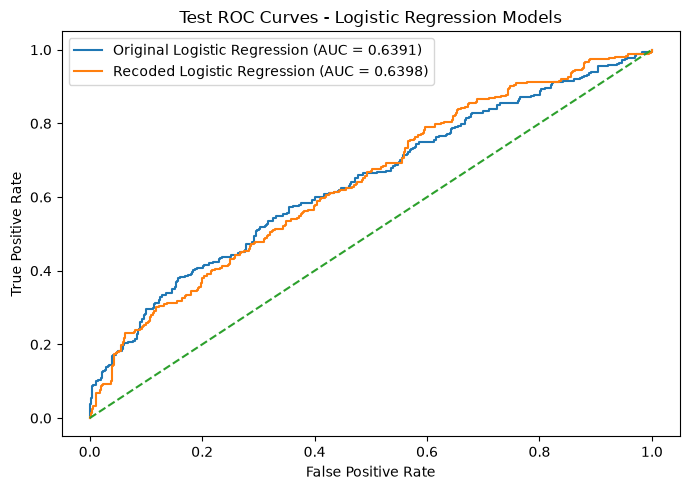

In [40]:
fpr_test_recoded, tpr_test_recoded, _ = roc_curve(
    y_test,
    test_probabilities_recoded
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Original Logistic Regression (AUC = {test_auc:.4f})"
)

plt.plot(
    fpr_test_recoded,
    tpr_test_recoded,
    label=f"Recoded Logistic Regression (AUC = {test_auc_recoded:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves - Logistic Regression Models")
plt.legend()

plt.tight_layout()
plt.show()

<b> Logistic Regression Findings </b>

-- The dataset was split into 80% training data and 20% test data<br>
while keeping the response distribution similar in both sets.

-- Missing NPS values were filled using the median calculated only from<br>
the training data to avoid data leakage.

-- The first logistic regression model used total_sales,<br>
unique_products, number_of_invoices, nps, n_comp,<br>
n_communications and loyalty.

-- NPS, loyalty and number of communications had positive effects on<br>
campaign response, while number of complaints had a negative effect.

-- Total sales, unique products and number of invoices were not<br>
statistically significant in the first model.

-- The VIF values were low for all variables, indicating that<br>
multicollinearity was not a major problem.

-- The original logistic regression achieved a training ROC AUC of<br>
0.6725 and a test ROC AUC of 0.6391.

-- A threshold of 0.4038 was selected using the training data to balance<br>
sensitivity and specificity.

-- Using this threshold, the original model achieved a test sensitivity<br>
of 0.5756, specificity of 0.6382 and balanced accuracy of 0.6069.

-- A second logistic regression model was created using recoded versions<br>
of NPS, complaints and number of communications.

-- The Promoter NPS category showed perfect separation in the training<br>
data, so Passive and Promoter were combined into a Non-Detractor group.

-- The recoded model achieved a training ROC AUC of 0.6903 and a test<br>
ROC AUC of 0.6398.

-- The recoded model had the highest test AUC, but the improvement over<br>
the original model was very small and did not represent a meaningful<br>
practical improvement.